# Week 8 and 9 Assignment - Practical Tasks
**Name:** Arun Sagar Rai

## Task 1: Linear Regression - Boston Housing Dataset

R² Score: 0.58


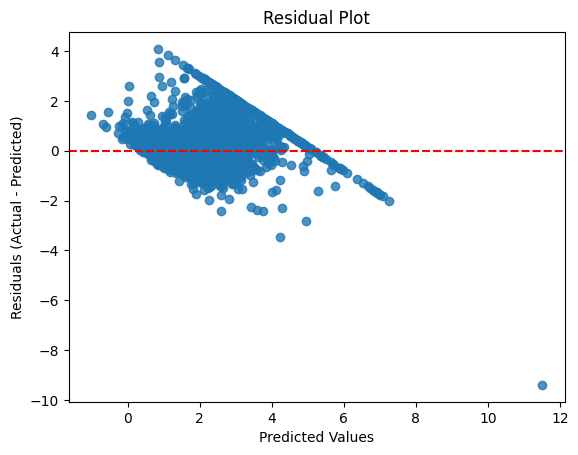

In [5]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MEDV')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

# Residual plot (no lowess)
residuals = y_test - y_pred
sns.residplot(x=y_pred, y=residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()



## Task 2: Logistic Regression - Titanic Dataset

Confusion Matrix:
[[71 16]
 [20 36]]
Accuracy: 0.75
Precision: 0.69
Recall: 0.64
F1 Score: 0.67


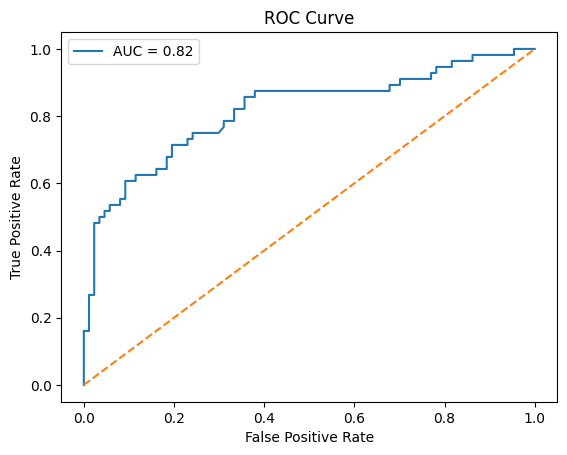

In [6]:

import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']]
df.dropna(inplace=True)

# Encode categorical variables
df['sex'] = LabelEncoder().fit_transform(df['sex'])

# Split data
X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")

# ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Task 3: KNN Classifier

In [7]:

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train and evaluate for different K values
for metric in ['euclidean', 'manhattan']:
    print(f"--- Using {metric} distance ---")
    for k in [1, 3, 5, 7]:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X, y)
        y_pred = model.predict(X)
        acc = accuracy_score(y, y_pred)
        print(f"K={k} => Accuracy: {acc:.2f}")


--- Using euclidean distance ---
K=1 => Accuracy: 1.00
K=3 => Accuracy: 0.95
K=5 => Accuracy: 0.95
K=7 => Accuracy: 0.97
--- Using manhattan distance ---
K=1 => Accuracy: 1.00
K=3 => Accuracy: 0.96
K=5 => Accuracy: 0.96
K=7 => Accuracy: 0.95


## Task 4: SVM Classifier

--- LINEAR Kernel ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.70      0.76      0.73        50
           2       0.74      0.70      0.72        50

    accuracy                           0.81       150
   macro avg       0.82      0.81      0.81       150
weighted avg       0.82      0.81      0.81       150



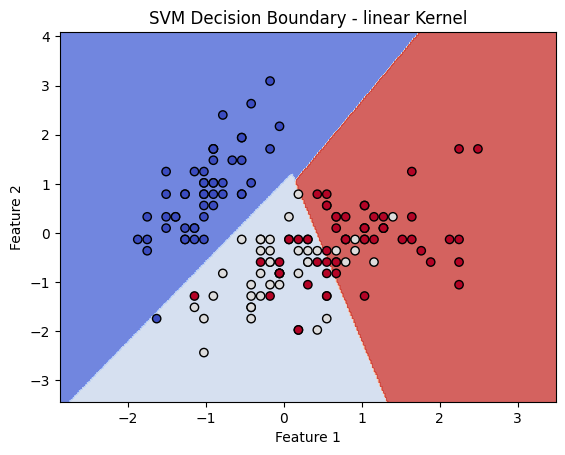

--- RBF Kernel ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.73      0.72      0.73        50
           2       0.73      0.76      0.75        50

    accuracy                           0.82       150
   macro avg       0.82      0.82      0.82       150
weighted avg       0.82      0.82      0.82       150



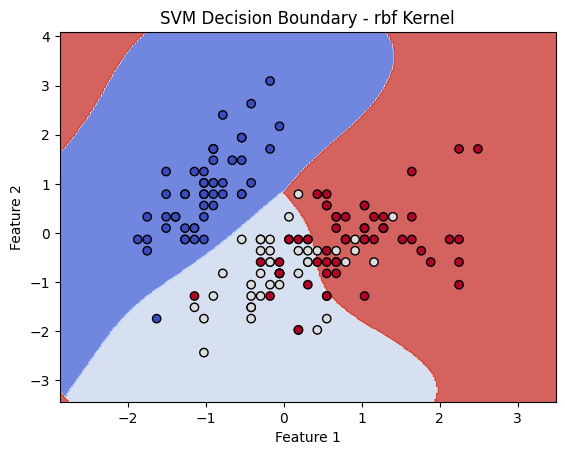

In [8]:

from sklearn.svm import SVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# 2D dataset for visualization (first two features of iris)
X_2D = X[:, :2]

# Train SVM with linear and RBF kernels
for kernel in ['linear', 'rbf']:
    clf = SVC(kernel=kernel)
    clf.fit(X_2D, y)

    print(f"--- {kernel.upper()} Kernel ---")
    print(classification_report(y, clf.predict(X_2D)))

    # Plot decision boundary
    h = .02
    x_min, x_max = X_2D[:, 0].min() - 1, X_2D[:, 0].max() + 1
    y_min, y_max = X_2D[:, 1].min() - 1, X_2D[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X_2D[:, 0], X_2D[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(f"SVM Decision Boundary - {kernel} Kernel")
    plt.show()


## Task 5: Cross-validation & Hyperparameter Tuning

In [9]:

from sklearn.model_selection import RandomizedSearchCV

# RandomizedSearchCV for KNN
params = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
search = RandomizedSearchCV(knn, params, cv=5, scoring='accuracy', n_iter=5)
search.fit(X, y)

print("Best Parameters:", search.best_params_)
print(f"Best Cross-Validated Accuracy: {search.best_score_:.2f}")


Best Parameters: {'n_neighbors': 5, 'metric': 'euclidean'}
Best Cross-Validated Accuracy: 0.96


## Task 6: Bayesian Optimization

In [12]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris

# Load example data
data = load_iris()
X, y = data.data, data.target

# Pipeline
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

# Print step names
print(pipe.named_steps)

# Search space
search_space = {
    'kneighborsclassifier__n_neighbors': Integer(1, 10),
    'kneighborsclassifier__metric': Categorical(['euclidean', 'manhattan'])
}

# Bayesian optimization
opt = BayesSearchCV(pipe, search_spaces=search_space, n_iter=10, cv=3, scoring='accuracy', random_state=42)
opt.fit(X, y)

print("Best Parameters via Bayesian Optimization:", opt.best_params_)
print(f"Best Accuracy: {opt.best_score_:.2f}")


{'standardscaler': StandardScaler(), 'kneighborsclassifier': KNeighborsClassifier()}
Best Parameters via Bayesian Optimization: OrderedDict({'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 8})
Best Accuracy: 0.96
